# Deteccion de anomalías

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Mejores parámetros: {'contamination': 0.05, 'max_samples': 'auto', 'n_estimators': 50, 'random_state': 42}

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    Anomalía       0.88      1.00      0.94        15
      Normal       1.00      0.99      1.00       300

    accuracy                           0.99       315
   macro avg       0.94      1.00      0.97       315
weighted avg       0.99      0.99      0.99       315



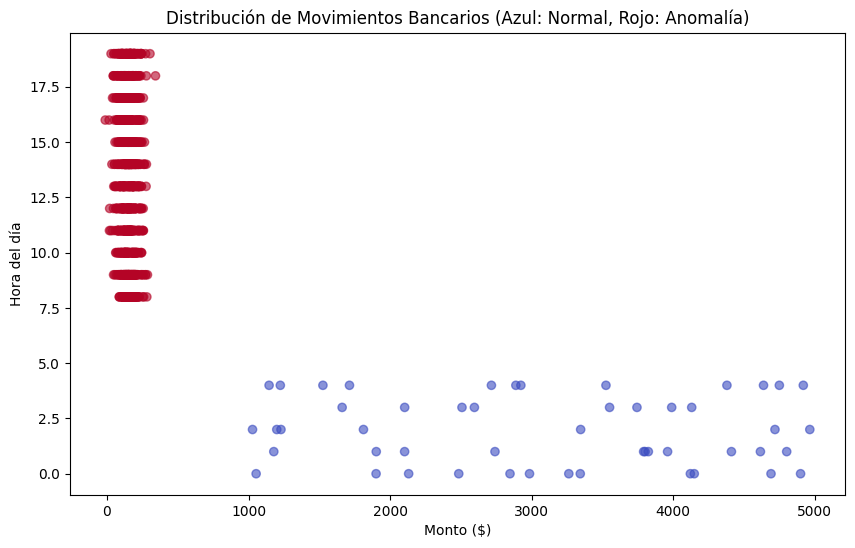

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, f1_score, make_scorer
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. GENERACIÓN DE DATASET SINTÉTICO
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 1000
n_anomalies = 50

# Transacciones normales (Montos bajos, horario laboral)
normal_amounts = np.random.normal(loc=150, scale=50, size=n_samples)
normal_hours = np.random.randint(8, 20, size=n_samples) 

# Anomalías (Montos muy altos, horarios de madrugada)
anomaly_amounts = np.random.uniform(1000, 5000, size=n_anomalies) 
anomaly_hours = np.random.randint(0, 5, size=n_anomalies) 

# Consolidación de datos
amounts = np.concatenate([normal_amounts, anomaly_amounts])
hours = np.concatenate([normal_hours, anomaly_hours])
# Etiquetas: 1 para normal, -1 para anomalía (estándar de scikit-learn para outliers)
labels = np.concatenate([np.ones(n_samples), -1 * np.ones(n_anomalies)]) 

df = pd.DataFrame({
    'Monto': amounts,
    'Hora': hours,
    'Es_Anomalia': labels
})

# Mezclar el dataset
df = df.sample(frac=1).reset_index(drop=True)

# ---------------------------------------------------------
# 2. PREPROCESAMIENTO
# ---------------------------------------------------------
# Escalamos los datos ya que Isolation Forest se beneficia de magnitudes comparables
X = df[['Monto', 'Hora']]
y_true = df['Es_Anomalia']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba (estratificado para mantener proporción de anomalías)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true, test_size=0.3, random_state=42, stratify=y_true
)

# ---------------------------------------------------------
# 3. FINE-TUNING CON GRID SEARCH
# ---------------------------------------------------------
# Definimos el espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': ['auto', 0.8, 0.5],
    'contamination': [0.03, 0.05, 0.1], # Proporción esperada de anomalías
    'random_state': [42]
}

# Usamos F1-Score enfocándonos en la clase -1 (anomalías) como métrica de optimización
f1_anomaly_scorer = make_scorer(f1_score, pos_label=-1)

grid_search = GridSearchCV(
    IsolationForest(),
    param_grid,
    scoring=f1_anomaly_scorer,
    cv=3,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Mejor modelo seleccionado
best_model = grid_search.best_estimator_
print(f"Mejores parámetros: {grid_search.best_params_}")

# ---------------------------------------------------------
# 4. EVALUACIÓN DE MÉTRICAS
# ---------------------------------------------------------
y_pred = best_model.predict(X_test)

print("\n--- Reporte de Clasificación ---")
# Mapeamos -1 a 'Anomalía' y 1 a 'Normal' para el reporte
print(classification_report(y_test, y_pred, target_names=['Anomalía', 'Normal']))

# Visualización simple
plt.figure(figsize=(10, 6))
plt.scatter(df['Monto'], df['Hora'], c=df['Es_Anomalia'], cmap='coolwarm', alpha=0.6)
plt.title('Distribución de Movimientos Bancarios (Azul: Normal, Rojo: Anomalía)')
plt.xlabel('Monto ($)')
plt.ylabel('Hora del día')
plt.show()